In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [2]:
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.check_multicollinearity import check_multicollinearity 
from utils.evaluate_model import evaluate_model

In [3]:
MACRO_COLS = ['CPI_Change', 'Rate_Change', 'GDP_Growth', 'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread']
LAGGED_COLS =[
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
    ]
# remove some features cols and run several times to see how it affects the performance

In [4]:
df = pd.read_csv('../data/processed/processed_data.csv',parse_dates=['Date'])

# df.info()

In [5]:
def train_linear_model(df, macro_cols, model_name):
    """
    Train and evaluate a Linear Regression model using selected features.
    Returns evaluation results and coefficient table.
    """
    # Split data
    splits_data = data_split(df, macro_cols)
    X_train = splits_data['X_train']
    y_train = splits_data['y_train']
    X_test  = splits_data['X_test']
    y_test  = splits_data['y_test']

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Evaluate
    ev_result = evaluate_model(
        model, X_train_scaled, y_train,
        X_test_scaled, y_test, model_name
    )

    # Coefficients
    coef_df = pd.DataFrame({
        'Feature': macro_cols,
        'Coefficient': model.coef_,
        'Abs_Coef': np.abs(model.coef_)
    }).sort_values('Abs_Coef', ascending=False)

    print("\nCOEFFICIENTS:")
    print(coef_df.to_string(index=False))

    return ev_result, coef_df, model

In [6]:
# MODEL 1: Linear Regression (7 variables, NO lags)
ev1, coef1, model1 = train_linear_model(df, MACRO_COLS, "Model 1 - Baseline")


  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread
  Model 1 - Baseline
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3766     0.0751
  RMSE (%)                       3.222      4.826
  MAE (%)                        2.434      3.545
  Directional Acc (%)            75.43      73.91

COEFFICIENTS:
      Feature  Coefficient  Abs_Coef
   VIX_Change    -2.381333  2.381333
Credit_Spread    -0.792480  0.792480
   USD_Change    -0.545496  0.545496
 Unemp_Change    -0.291311  0.291311
   CPI_Change    -0.225185  0.225185
  Rate_Change    -0.206304  0.206304
   GDP_Growth    -0.079954  0.079954


In [7]:

# MODEL 2: Linear Regression With lags
ev2, coef2, model2 = train_linear_model(df, MACRO_COLS + LAGGED_COLS, "Model 2 - With Lags")



  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2
  Model 2 - With Lags
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3901    -0.3961
  RMSE (%)                       3.187      5.930
  MAE (%)                        2.409      4.286
  Directional Acc (%)            74.86      65.22

COEFFICIENTS:
           Feature  Coefficient  Abs_Coef
        VIX_Change    -2.396863  2.396863
   GDP_Growth_lag2    -1.098706  1.098706
        GDP_Growth     1.021864  1.021864
     Credit_Spread    -0.606216  0.606216
        USD_Change    -0.537686  0.537686
 Unemp_Change_lag1    -0.317521  0.317521
        CPI_Change    -0.296629  0.296629
      Unemp_Change    -0.289599  0.289599
       Rate_Change    -0.284578  0.284578
   CPI_Change_lag1     0.243983  0.243983
Credit_Spread_lag2     

In [8]:
# Check for multicollinearity

# Split data
splits_data = data_split(df, MACRO_COLS + LAGGED_COLS)
X_train_lagged = splits_data['X_train']
y_train_lagged = splits_data['y_train']
X_test_lagged  = splits_data['X_test']
y_test_lagged  = splits_data['y_test']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lagged)
X_test_scaled  = scaler.transform(X_test_lagged)

X_train_lagged_df = pd.DataFrame(X_train_lagged, columns=MACRO_COLS + LAGGED_COLS)
print("\nMULTICOLLINEARITY CHECK (VIF):")
vif_results = check_multicollinearity(X_train_lagged_df, threshold=5.0)


  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2

MULTICOLLINEARITY CHECK (VIF):

Variance Inflation Factor (VIF):
           Feature       VIF Concern
   GDP_Growth_lag2 89.635238    High
        GDP_Growth 89.230883    High
     Credit_Spread 52.412648    High
Credit_Spread_lag2 50.373382    High
        CPI_Change  2.232127      OK
   CPI_Change_lag1  1.977570      OK
 Unemp_Change_lag1  1.295880      OK
      Unemp_Change  1.261845      OK
       Rate_Change  1.242026      OK
        VIX_Change  1.106060      OK
        USD_Change  1.088589      OK

Note: VIF > 5.0 indicates multicollinearity concern


In [9]:

# MODEL 3: Linear Regression With Combining lags
FEATURE_COLS = [
    'CPI_Change_lag1', 'Rate_Change', 'GDP_Growth_lag2', 'Unemp_Change_lag1',
    'USD_Change', 'VIX_Change', 'Credit_Spread_lag2']
ev3, coef3, model3 = train_linear_model(df, FEATURE_COLS, "Model 3 - Mixed Lags")



  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2
  Model 3 - Mixed Lags
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3739     0.0853
  RMSE (%)                       3.229      4.800
  MAE (%)                        2.458      3.527
  Directional Acc (%)            73.99      69.57

COEFFICIENTS:
           Feature  Coefficient  Abs_Coef
        VIX_Change    -2.456406  2.456406
Credit_Spread_lag2    -0.786730  0.786730
        USD_Change    -0.514024  0.514024
 Unemp_Change_lag1    -0.342878  0.342878
   GDP_Growth_lag2    -0.322249  0.322249
   CPI_Change_lag1     0.247419  0.247419
       Rate_Change    -0.138638  0.138638


In [10]:
# Split data
splits_data = data_split(df, FEATURE_COLS)
X_train_4 = splits_data['X_train']
y_train_4 = splits_data['y_train']
X_test_4  = splits_data['X_test']
y_test_4  = splits_data['y_test']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_4)
X_test_scaled  = scaler.transform(X_test_4)

X_train_4_df = pd.DataFrame(X_train_4, columns=FEATURE_COLS)
print("\nMULTICOLLINEARITY CHECK (VIF):")
vif_results = check_multicollinearity(X_train_4_df, threshold=5.0)


  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2

MULTICOLLINEARITY CHECK (VIF):

Variance Inflation Factor (VIF):
           Feature      VIF Concern
   GDP_Growth_lag2 3.054825      OK
Credit_Spread_lag2 2.754052      OK
   CPI_Change_lag1 1.527702      OK
 Unemp_Change_lag1 1.254971      OK
       Rate_Change 1.119916      OK
        VIX_Change 1.055421      OK
        USD_Change 1.008708      OK

Note: VIF > 5.0 indicates multicollinearity concern


In [11]:
alphas = np.logspace(-3, 5, 100)

# Manually compute CV score for each alpha
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, 
        X_train_4, 
        y_train_4, 
        cv=5, 
        scoring='r2'
    )
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

# Find best alpha manually
best_alpha = alphas[np.argmax(cv_scores)]
print(f"Best alpha: {best_alpha:.4f}")

Best alpha: 312.5716


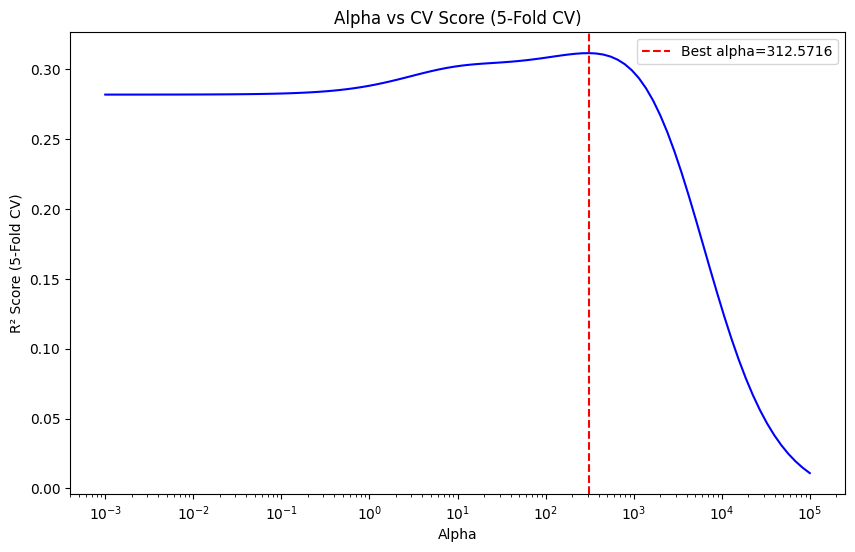

In [12]:
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, cv_scores, color='blue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xlabel('Alpha')
plt.ylabel('R² Score (5-Fold CV)')
plt.title('Alpha vs CV Score (5-Fold CV)')
plt.legend()
plt.show()

In [13]:

# Train final Ridge model with best alpha
# MODEL 4: Ridge Regression

print("\n" + "="*50)
print("MODEL 4: Ridge Regression")
print("="*50)

model_4 = Ridge(alpha=best_alpha)
model_4.fit(X_train_4, y_train_4)

# Predict
y_train_pred_4 = model_4.predict(X_train_4)
y_test_pred_4 = model_4.predict(X_test_4)

# Evaluate
ev_result4 = evaluate_model(model_4, X_train_4, y_train_4, X_test_4, y_test_4, "Model 4 - Test")

# Print coefficients (on scaled features)
coef_df_4 = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': model_4.coef_,
    'Abs_Coef': np.abs(model_4.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS (on standardized scale):")
print(coef_df_4.to_string(index=False))


MODEL 4: Ridge Regression
  Model 4 - Test
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3456     0.3225
  RMSE (%)                       3.302      4.131
  MAE (%)                        2.488      3.213
  Directional Acc (%)            73.41      71.01

COEFFICIENTS (on standardized scale):
           Feature  Coefficient  Abs_Coef
        VIX_Change    -0.608438  0.608438
        USD_Change    -0.220238  0.220238
Credit_Spread_lag2    -0.168372  0.168372
   GDP_Growth_lag2     0.128750  0.128750
   CPI_Change_lag1     0.106802  0.106802
 Unemp_Change_lag1    -0.062135  0.062135
       Rate_Change    -0.013509  0.013509


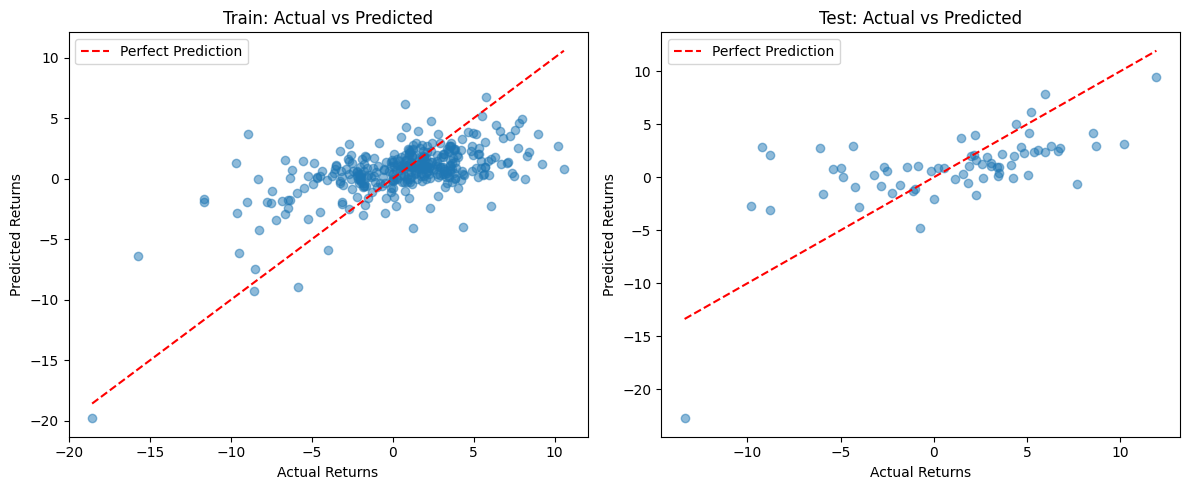

In [14]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1, 2, 1)
plt.scatter(y_train_lagged, y_train_pred_4, alpha=0.5)
plt.plot([y_train_lagged.min(), y_train_lagged.max()],
         [y_train_lagged.min(), y_train_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Train: Actual vs Predicted')
plt.legend()

# Test
plt.subplot(1, 2, 2)
plt.scatter(y_test_lagged, y_test_pred_4, alpha=0.5)
plt.plot([y_test_lagged.min(), y_test_lagged.max()],
         [y_test_lagged.min(), y_test_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Test: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.show()

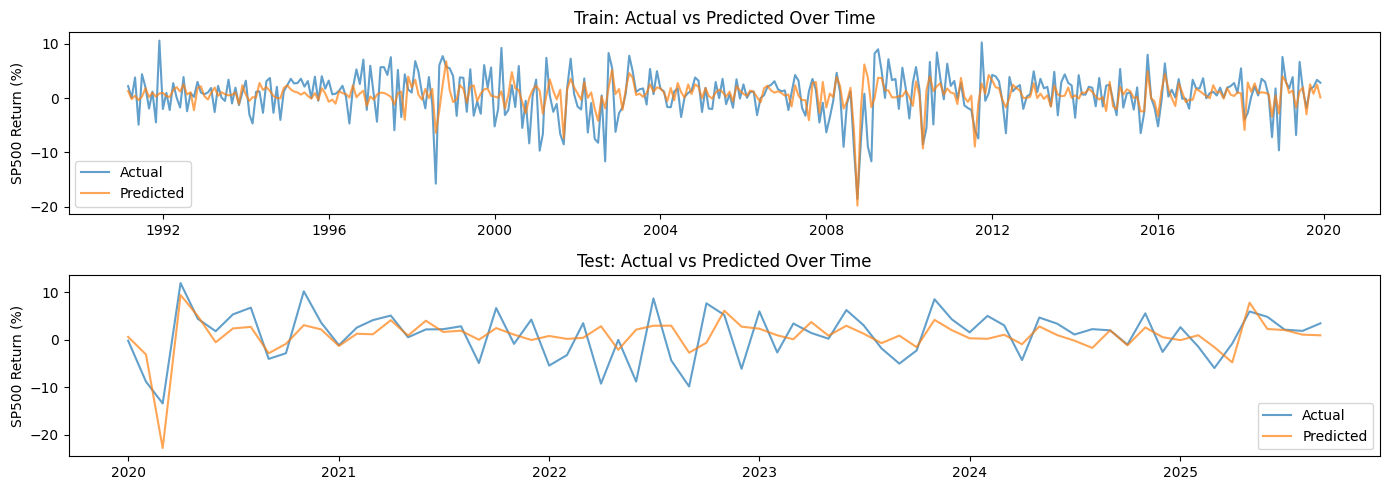

In [15]:
plt.figure(figsize=(14, 5))

dates_train,dates_test = splits_data['dates_train'], splits_data['dates_test']  
# Train
plt.subplot(2, 1, 1)
plt.plot(dates_train, y_train_lagged, label='Actual', alpha=0.7)
plt.plot(dates_train, y_train_pred_4,  label='Predicted', alpha=0.7)
plt.title('Train: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

# Test
plt.subplot(2, 1, 2)
plt.plot(dates_test, y_test_lagged, label='Actual', alpha=0.7)
plt.plot(dates_test, y_test_pred_4,  label='Predicted', alpha=0.7)
plt.title('Test: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

plt.tight_layout()
plt.show()

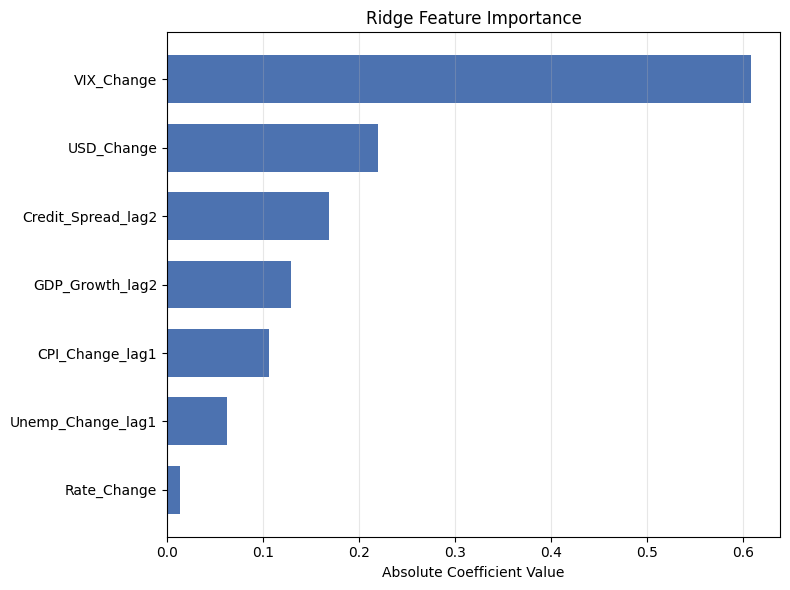

In [16]:
coef_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Coefficient': np.abs(model_4.coef_)
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'],color='#4C72B0', height=0.7)
plt.xlabel('Absolute Coefficient Value')
plt.title('Ridge Feature Importance')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [17]:
import pickle

# Save the fitted ridge model
with open('ridge_model.pkl', 'wb') as f:
    pickle.dump(model_4, f)

print("  Ridge model saved → ridge_model.pkl")

  Ridge model saved → ridge_model.pkl


In [18]:
import shap


explainer    = shap.LinearExplainer(model_4,X_train_4)

shap_train   = explainer.shap_values(X_train_4)
shap_test    = explainer.shap_values(X_test_4)

base_value   = explainer.expected_value
print(f"  Base value (mean prediction) : {base_value:.4f}")
print(f"  SHAP train matrix shape      : {shap_train.shape}")
print(f"  SHAP test  matrix shape      : {shap_test.shape}")

if not isinstance(X_train_4, pd.DataFrame):
    X_train_4 = pd.DataFrame(X_train_4, columns=FEATURE_COLS)

if not isinstance(X_test_4, pd.DataFrame):
    X_test_4 = pd.DataFrame(X_test_4, columns=FEATURE_COLS)

shap_train_df = pd.DataFrame(shap_train, columns=FEATURE_COLS)
shap_test_df  = pd.DataFrame(shap_test,  columns=FEATURE_COLS, index=X_test_4.index)

mean_abs_shap = shap_test_df.abs().mean().sort_values(ascending=False)

print("\nGlobal Feature Importance (Mean |SHAP|) on Test Set")
for feat, val in mean_abs_shap.items():
    bar = '█' * int(val * 20)
    print(f"  {feat:<25} {val:.4f}  {bar}")

  Base value (mean prediction) : 0.7799
  SHAP train matrix shape      : (346, 7)
  SHAP test  matrix shape      : (69, 7)

Global Feature Importance (Mean |SHAP|) on Test Set
  VIX_Change                2.0315  ████████████████████████████████████████
  GDP_Growth_lag2           0.4706  █████████
  USD_Change                0.2978  █████
  CPI_Change_lag1           0.0843  █
  Credit_Spread_lag2        0.0353  
  Unemp_Change_lag1         0.0239  
  Rate_Change               0.0018  


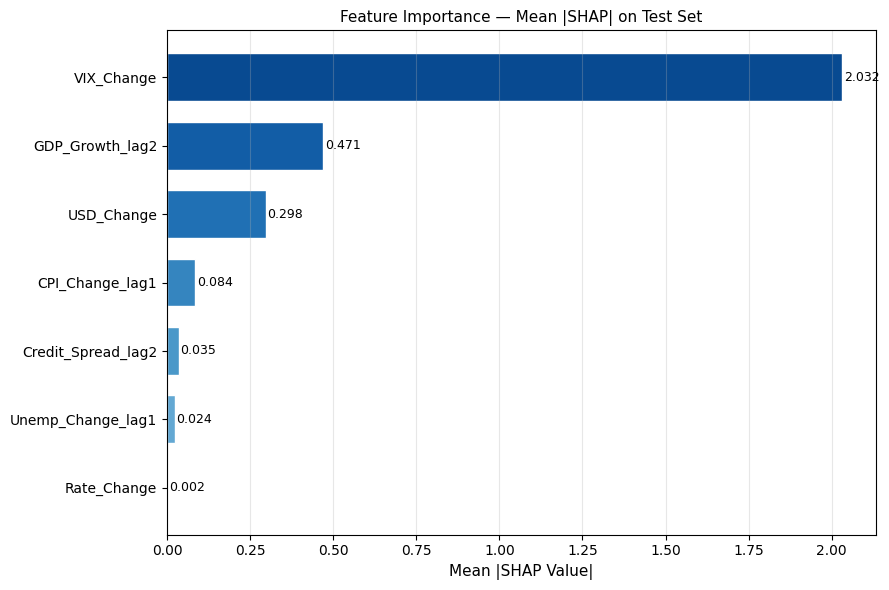

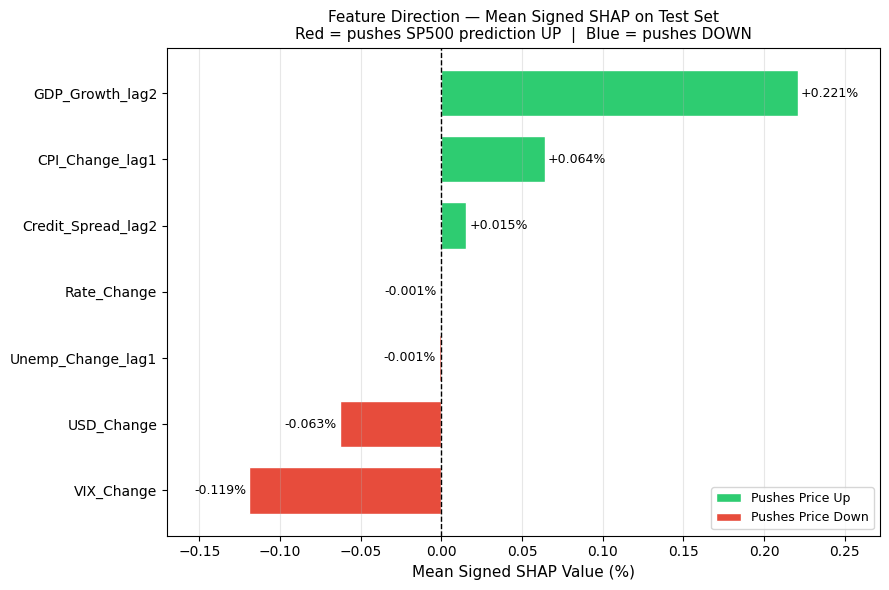

In [19]:
from src.shap_plots import plot_shap_importance, plot_shap_direction
plot_shap_importance(mean_abs_shap)
plot_shap_direction(shap_test_df)